In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
# Required libraries

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

 

In [2]:
df = pd.read_csv("bankChurners.csv")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [5]:
df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})


In [6]:
df = pd.get_dummies(df, columns=['Marital_Status', 'Card_Category'], drop_first=True)

# Converts to int (0/1) instead of bool
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [7]:
education_order = [
    ['Uneducated', 'High School', 'College',
     'Graduate', 'Post-Graduate', 'Doctorate', 'Unknown']
]

income_order = [
    ['Unknown', 'Less than $40K', '$40K - $60K',
     '$60K - $80K', '$80K - $120K', '$120K +']
]

ord_enc_edu = OrdinalEncoder(categories=education_order)
df['Education_Level'] = ord_enc_edu.fit_transform(df[['Education_Level']])

ord_enc_inc = OrdinalEncoder(categories=income_order)
df['Income_Category'] = ord_enc_inc.fit_transform(df[['Income_Category']])

In [8]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,768805383,0,45,0,3,1.0,3.0,39,5,1,...,1.625,0.061,0.000093,0.99991,1,0,0,0,0,0
1,818770008,0,49,1,5,3.0,1.0,44,6,1,...,3.714,0.105,0.000057,0.99994,0,1,0,0,0,0
2,713982108,0,51,0,3,3.0,4.0,36,4,1,...,2.333,0.000,0.000021,0.99998,1,0,0,0,0,0
3,769911858,0,40,1,4,1.0,1.0,34,3,4,...,2.333,0.760,0.000134,0.99987,0,0,1,0,0,0
4,709106358,0,40,0,3,0.0,3.0,21,5,1,...,2.500,0.000,0.000022,0.99998,1,0,0,0,0,0


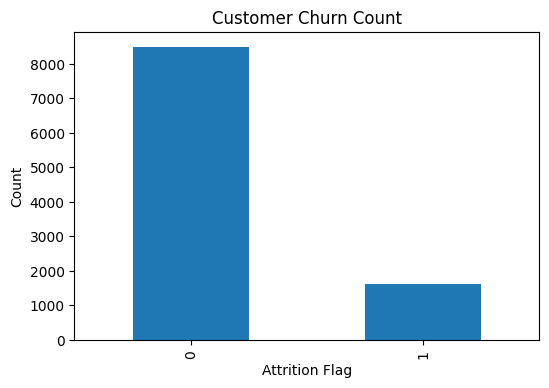

In [9]:
plt.figure(figsize=(6,4))
df["Attrition_Flag"].value_counts().plot(kind='bar')
plt.title("Customer Churn Count")
plt.xlabel("Attrition Flag")
plt.ylabel("Count")

plt.show()

In [10]:
X = df.drop(columns=[
    'Attrition_Flag',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]).values

y = df['Attrition_Flag'].values


In [11]:
y

array([0, 0, 0, ..., 1, 1, 1], shape=(10127,))

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [14]:
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, cw))
print(f"Class weights: {class_weights}")

Class weights: {np.int64(0): np.float64(0.5957943925233645), np.int64(1): np.float64(3.1097560975609757)}


In [15]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(X_train_s, y_train)

print("Before balancing:")
print(pd.Series(y_train).value_counts())

print("\nAfter balancing:")
print(pd.Series(y_train_balanced).value_counts())

Before balancing:
0    5778
1    1107
Name: count, dtype: int64

After balancing:
0    5778
1    5778
Name: count, dtype: int64


In [16]:
log_model = LogisticRegression(max_iter=1000, random_state=42 , class_weight='balanced')

log_model.fit(X_train_balanced, y_train_balanced)

y_pred_log = log_model.predict(X_test_s)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.8558736426456071
Precision: 0.533066132264529
Recall: 0.8184615384615385
F1 Score: 0.6456310679611651

Confusion Matrix:
[[1468  233]
 [  59  266]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1701
           1       0.53      0.82      0.65       325

    accuracy                           0.86      2026
   macro avg       0.75      0.84      0.78      2026
weighted avg       0.89      0.86      0.87      2026



In [17]:
nb_model = GaussianNB()

nb_model.fit(X_train_balanced, y_train_balanced)

y_pred_nb = nb_model.predict(X_test_s)

print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results
Accuracy: 0.8000987166831195
Precision: 0.4261992619926199
Recall: 0.7107692307692308
F1 Score: 0.532871972318339

Confusion Matrix:
[[1390  311]
 [  94  231]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.87      1701
           1       0.43      0.71      0.53       325

    accuracy                           0.80      2026
   macro avg       0.68      0.76      0.70      2026
weighted avg       0.85      0.80      0.82      2026



In [18]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_balanced, y_train_balanced)

y_pred_knn = knn_model.predict(X_test_s)

print("KNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Results
Accuracy: 0.8553800592300099
Precision: 0.5344827586206896
Recall: 0.7630769230769231
F1 Score: 0.6286438529784537

Confusion Matrix:
[[1485  216]
 [  77  248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      1701
           1       0.53      0.76      0.63       325

    accuracy                           0.86      2026
   macro avg       0.74      0.82      0.77      2026
weighted avg       0.88      0.86      0.87      2026



In [19]:
svc_model = SVC(random_state=42)

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(
    estimator=svc_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svc.fit(X_train_balanced, y_train_balanced)

print("Best Parameters:")
print(grid_svc.best_params_)

print("\nBest F1 Score:")
print(grid_svc.best_score_)

Best Parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Best F1 Score:
0.9681887241694497


In [20]:
best_svc_model = grid_svc.best_estimator_

y_pred_svc = best_svc_model.predict(X_test_s)

print("SVC Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc))
print("Recall:", recall_score(y_test, y_pred_svc))
print("F1 Score:", f1_score(y_test, y_pred_svc))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc))

SVC Results
Accuracy: 0.918558736426456
Precision: 0.7366863905325444
Recall: 0.7661538461538462
F1 Score: 0.751131221719457

Confusion Matrix:
[[1612   89]
 [  76  249]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1701
           1       0.74      0.77      0.75       325

    accuracy                           0.92      2026
   macro avg       0.85      0.86      0.85      2026
weighted avg       0.92      0.92      0.92      2026



In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeClassifier(random_state=42)

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_dt.fit(X_train_balanced, y_train_balanced)

print("Best Parameters for Decision Tree:")
print(grid_dt.best_params_)

print("\nBest F1 Score:")
print(grid_dt.best_score_)

Best Parameters for Decision Tree:
{'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best F1 Score:
0.9786439089809379


In [22]:
best_dt_model = grid_dt.best_estimator_

y_pred_dt = best_dt_model.predict(X_test_s)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.9259624876604146
Precision: 0.7946127946127947
Recall: 0.7261538461538461
F1 Score: 0.7588424437299035

Confusion Matrix:
[[1640   61]
 [  89  236]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1701
           1       0.79      0.73      0.76       325

    accuracy                           0.93      2026
   macro avg       0.87      0.85      0.86      2026
weighted avg       0.92      0.93      0.92      2026



In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(random_state=42)

rf_param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train_balanced, y_train_balanced)

print("Best Parameters for Random Forest:")
print(random_rf.best_params_)

print("\nBest F1 Score:")
print(random_rf.best_score_)

Best Parameters for Random Forest:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'gini', 'bootstrap': False}

Best F1 Score:
0.992441027209518


In [24]:
best_rf_model = random_rf.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_s)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9550839091806516
Precision: 0.9431818181818182
Recall: 0.7661538461538462
F1 Score: 0.8455008488964346

Confusion Matrix:
[[1686   15]
 [  76  249]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1701
           1       0.94      0.77      0.85       325

    accuracy                           0.96      2026
   macro avg       0.95      0.88      0.91      2026
weighted avg       0.95      0.96      0.95      2026



In [25]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'KNN',
        'SVC with GridSearchCV',
        'Decision Tree with GridSearchCV',
        'Random Forest with RandomizedSearchCV'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svc),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svc),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svc),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.855874,0.533066,0.818462,0.645631
1,Naive Bayes,0.800099,0.426199,0.710769,0.532872
2,KNN,0.855380,0.534483,0.763077,0.628644
3,SVC with GridSearchCV,0.918559,0.736686,0.766154,0.751131
4,Decision Tree with GridSearchCV,0.925962,0.794613,0.726154,0.758842
5,Random Forest with RandomizedSearchCV,0.955084,0.943182,0.766154,0.845501


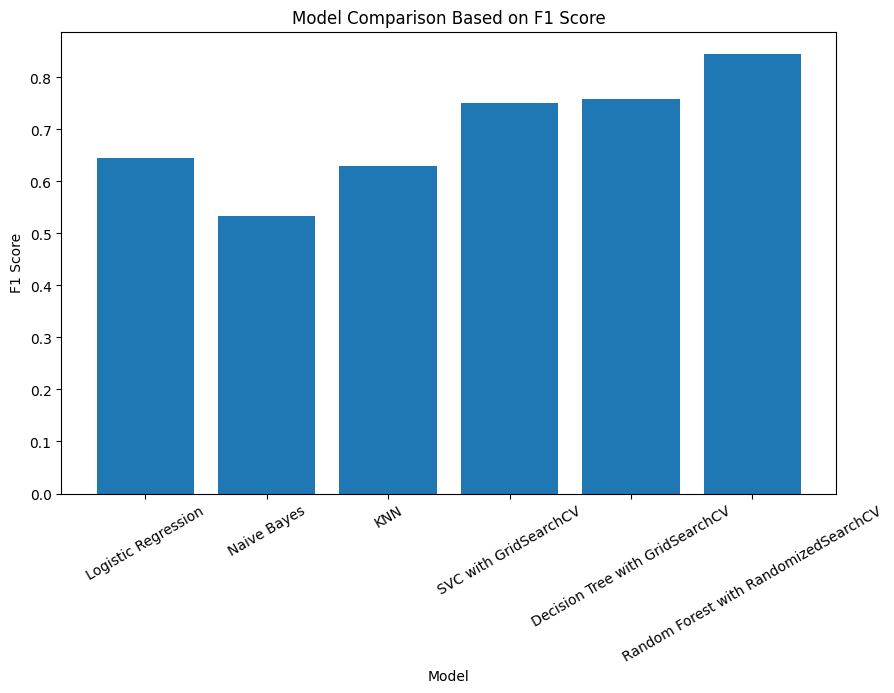

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(model_comparison['Model'], model_comparison['F1 Score'])

plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('Model Comparison Based on F1 Score')
plt.xticks(rotation=30)
plt.show()